# 2.12 Buenas Prácticas de Visualización de Datos

**Versión Python con Matplotlib y Seaborn**

Este notebook recorre, paso a paso, los principios fundamentales para crear visualizaciones efectivas. En cada tema veremos:

- 📖 La **teoría** detrás del principio.
- ❌ Un ejemplo de **mala práctica**.
- ✅ Un ejemplo de **buena práctica**.
- 💡 La **explicación** de por qué uno funciona mejor que el otro.

> **Idea central:** una buena visualización no busca decorar, sino *comunicar*. Cada elemento (color, tamaño, posición, tipografía) debe tener un propósito.

---

## 0. Configuración inicial

Importamos las librerías que usaremos en todo el notebook y fijamos una semilla aleatoria para que los resultados sean reproducibles.

In [1]:
# Librerías estándar para análisis y visualización
import numpy as np                  # Operaciones numéricas
import pandas as pd                 # Manejo de datos en tablas (DataFrames)
import matplotlib.pyplot as plt     # Visualización base
import seaborn as sns               # Visualización estadística (encima de matplotlib)
from matplotlib.ticker import FuncFormatter  # Para formatear números en los ejes

# Semilla para reproducibilidad: garantiza que los datos aleatorios
# sean siempre los mismos cada vez que se ejecuta el notebook.
np.random.seed(42)

# Configuración global recomendada para gráficos limpios
plt.rcParams['figure.dpi'] = 100        # Resolución de pantalla
plt.rcParams['savefig.dpi'] = 150       # Resolución al guardar
plt.rcParams['font.family'] = 'DejaVu Sans'  # Fuente legible y disponible

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


### Dataset de ejemplo

Crearemos un dataset ficticio de **ventas mensuales por categoría de producto** que usaremos en varios ejemplos. Trabajar con un mismo dataset facilita comparar técnicas.

In [2]:
# Generamos datos sintéticos de ventas
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

ventas = pd.DataFrame({
    'Mes': meses,
    'Electrónica': [120, 132, 145, 150, 160, 175, 180, 190, 205, 220, 240, 280],
    'Ropa':        [ 90,  95, 100, 110, 115, 120, 125, 130, 135, 140, 150, 200],
    'Hogar':       [ 70,  75,  78,  82,  85,  88,  92,  95,  98, 100, 105, 130],
    'Deportes':    [ 50,  55,  60,  62,  65,  70,  72,  74,  76,  78,  80,  95],
})

# Vista rápida del DataFrame
ventas.head()

,Mes,Electrónica,Ropa,Hogar,Deportes
0,Ene,120,90,70,50
1,Feb,132,95,75,55
2,Mar,145,100,78,60
3,Abr,150,110,82,62
4,May,160,115,85,65


---
## 1. Propósito claro: cada gráfico responde una pregunta

Antes de elegir el tipo de gráfico, debemos preguntarnos:

> **¿Qué pregunta quiero que el lector responda al ver esto?**

Si no podemos formular esa pregunta en una frase, probablemente el gráfico sobra o necesita reenfocarse.

**Ejemplo:** queremos responder *"¿Cómo evolucionaron las ventas de Electrónica durante el año?"*

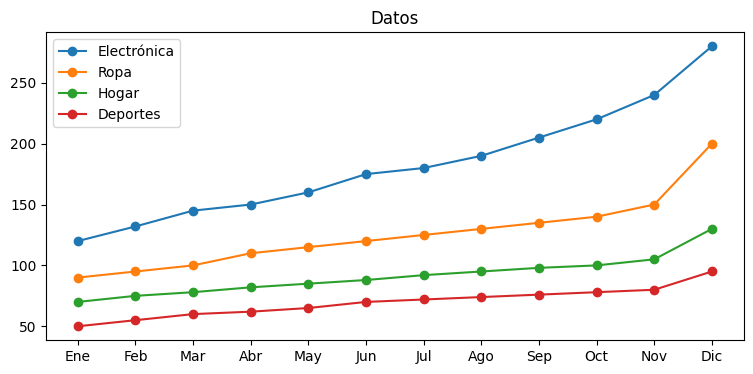

In [3]:
# ❌ MALA PRÁCTICA: gráfico sin un propósito claro
# Mostramos TODAS las categorías a la vez sin destacar nada,
# así el lector no sabe en qué fijarse.

fig, ax = plt.subplots(figsize=(9, 4))
for col in ['Electrónica', 'Ropa', 'Hogar', 'Deportes']:
    ax.plot(ventas['Mes'], ventas[col], marker='o')

ax.set_title('Datos')        # Título vacío de significado
ax.legend(['Electrónica', 'Ropa', 'Hogar', 'Deportes'])
plt.show()

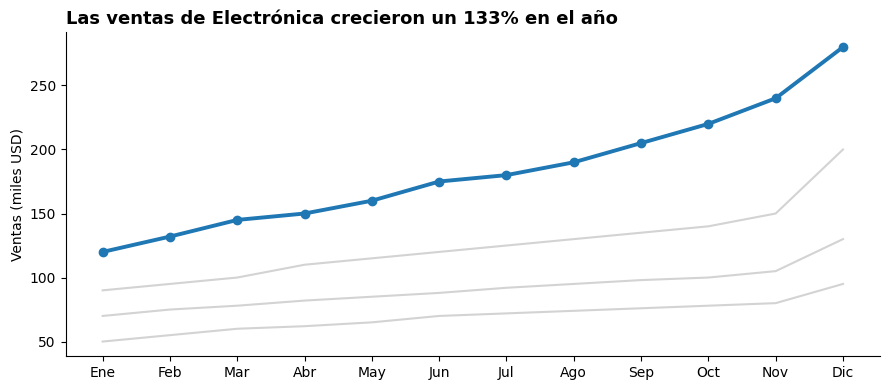

In [4]:
# ✅ BUENA PRÁCTICA: el gráfico responde una pregunta concreta.
# Destacamos la categoría de interés (Electrónica) y dejamos
# las demás en gris claro como contexto.

fig, ax = plt.subplots(figsize=(9, 4))

# Líneas de contexto (grises, sin protagonismo)
for col in ['Ropa', 'Hogar', 'Deportes']:
    ax.plot(ventas['Mes'], ventas[col], color='lightgray', linewidth=1.5)

# Línea protagonista
ax.plot(ventas['Mes'], ventas['Electrónica'],
        color='#1f77b4', linewidth=2.8, marker='o', label='Electrónica')

# Título que ya cuenta la historia
ax.set_title('Las ventas de Electrónica crecieron un 133% en el año',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Ventas (miles USD)')

# Quitamos bordes innecesarios para reducir ruido visual
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

💡 **¿Por qué la segunda funciona mejor?**

1. El **título** ya entrega la conclusión, no obliga al lector a deducirla.
2. Una sola serie está destacada → el ojo sabe a dónde mirar.
3. Las demás categorías siguen ahí como **contexto**, pero no compiten por atención.

---
## 2. Simplicidad efectiva: eliminar el ruido visual

Edward Tufte llamó **"chartjunk"** a todos los elementos decorativos que no aportan información: sombras, gradientes, fondos, bordes excesivos, efectos 3D…

Regla práctica: **si un elemento no añade información, quítalo**.

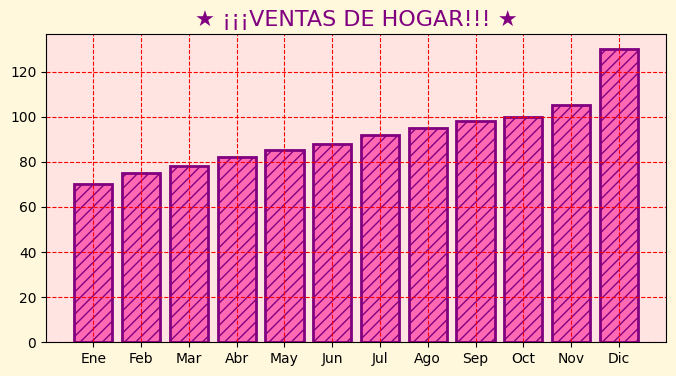

In [5]:
# ❌ MALA PRÁCTICA: muchos elementos decorativos que distraen
fig, ax = plt.subplots(figsize=(8, 4), facecolor='#fff8dc')  # Fondo crema innecesario

ax.bar(ventas['Mes'], ventas['Hogar'],
       color='hotpink', edgecolor='purple', linewidth=2, hatch='///')  # Patrón hatch

ax.set_facecolor('#ffe4e1')                   # Fondo del área de plot
ax.grid(True, color='red', linestyle='--')    # Cuadrícula chillona
ax.set_title('★ ¡¡¡VENTAS DE HOGAR!!! ★', fontsize=16, color='purple')
plt.show()

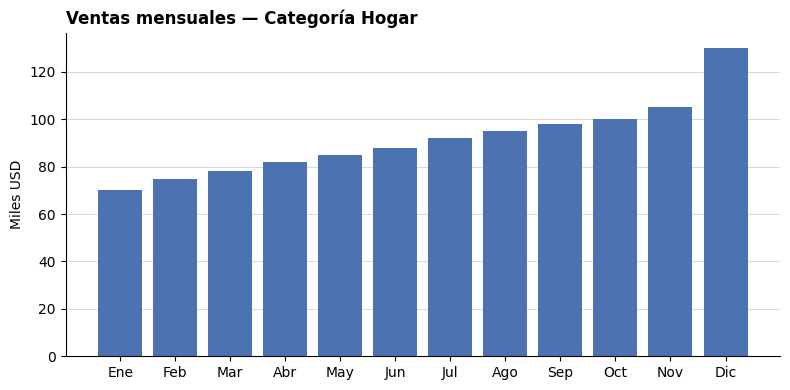

In [6]:
# ✅ BUENA PRÁCTICA: minimalista, solo lo necesario
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(ventas['Mes'], ventas['Hogar'], color='#4c72b0')

ax.set_title('Ventas mensuales — Categoría Hogar',
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('Miles USD')

# Cuadrícula sutil solo en el eje Y, ayuda a leer sin distraer
ax.yaxis.grid(True, color='lightgray', linewidth=0.6)
ax.set_axisbelow(True)  # La cuadrícula queda DETRÁS de las barras

# Eliminar bordes superfluos
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

💡 **Ratio dato-tinta** (Tufte): la mayor parte de la "tinta" del gráfico debe representar **datos**, no decoración. Cuando dudes, **quita** elementos hasta que el mensaje quede claro.

---
## 3. Jerarquía visual: guiar la mirada

El cerebro procesa la información visual con prioridades. Tres herramientas para guiar la mirada:

| Recurso | Uso recomendado |
|---|---|
| **Tamaño**   | Lo más grande se ve primero |
| **Color**    | Reserva colores intensos solo para lo importante |
| **Posición** | Lectura natural: arriba-abajo, izquierda-derecha |

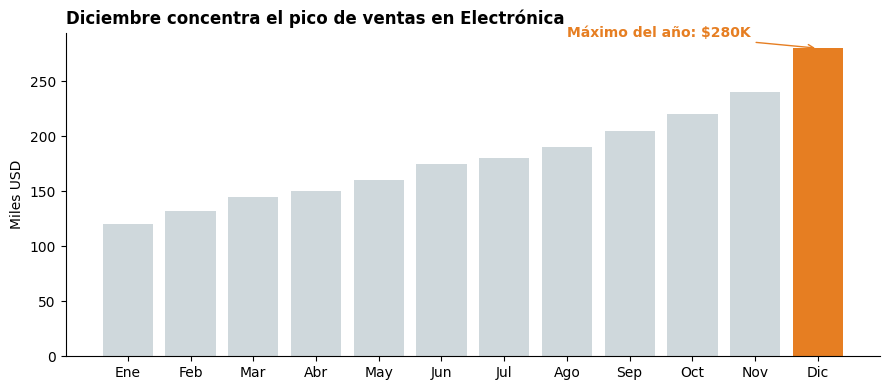

In [7]:
# Vamos a destacar el mes con MAYOR ventas en Electrónica.
# Identificamos el índice del valor máximo:
idx_max = ventas['Electrónica'].idxmax()

# Creamos una lista de colores: gris para todos, naranja para el máximo
colores = ['#cfd8dc'] * len(ventas)   # gris claro por defecto
colores[idx_max] = '#e67e22'          # naranja para destacar

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ventas['Mes'], ventas['Electrónica'], color=colores)

# Anotación que refuerza la jerarquía
ax.annotate(f'Máximo del año: ${ventas["Electrónica"].max()}K',
            xy=(idx_max, ventas['Electrónica'].max()),
            xytext=(idx_max - 4, ventas['Electrónica'].max() + 10),
            fontsize=10, color='#e67e22', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e67e22'))

ax.set_title('Diciembre concentra el pico de ventas en Electrónica',
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('Miles USD')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

💡 **La técnica del color destacado** es muy potente: 11 barras grises + 1 naranja → la mirada va directo al insight, sin necesidad de leer todas las etiquetas.

---
## 4. Consistencia gráfica

Cuando varios gráficos representan **la misma categoría** (por ejemplo, "Electrónica"), debe **mantenerse el mismo color** en todos. De lo contrario el lector se desorienta.

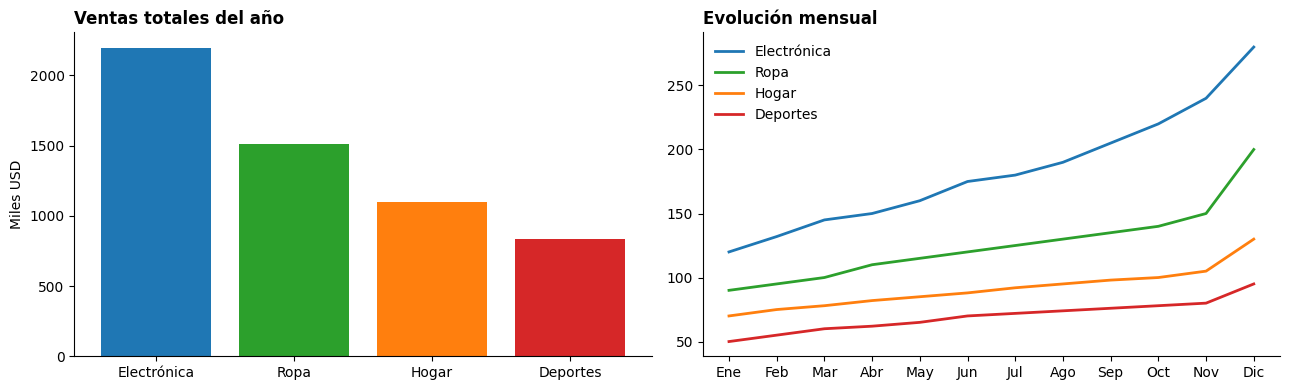

In [8]:
# Definimos UN diccionario de colores y lo reutilizamos siempre.
# Esta es la mejor manera de garantizar consistencia.
PALETA_CATEGORIAS = {
    'Electrónica': '#1f77b4',  # azul
    'Ropa':        '#2ca02c',  # verde
    'Hogar':       '#ff7f0e',  # naranja
    'Deportes':    '#d62728',  # rojo
}

# Dos gráficos distintos, MISMOS colores por categoría → consistente.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: total anual por categoría (barras)
totales = ventas[list(PALETA_CATEGORIAS)].sum()
axes[0].bar(totales.index, totales.values,
            color=[PALETA_CATEGORIAS[c] for c in totales.index])
axes[0].set_title('Ventas totales del año', loc='left', fontweight='bold')
axes[0].set_ylabel('Miles USD')

# Gráfico 2: evolución mensual (líneas)
for cat, color in PALETA_CATEGORIAS.items():
    axes[1].plot(ventas['Mes'], ventas[cat], color=color, label=cat, linewidth=2)
axes[1].set_title('Evolución mensual', loc='left', fontweight='bold')
axes[1].legend(frameon=False)

# Limpieza visual común
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

💡 **Truco profesional:** define la paleta como un **diccionario constante** al inicio del notebook. Si luego decides cambiar un color, lo cambias en un único lugar.

---
## 5. Uso correcto del color

Reglas básicas:

1. **Funcional**, no decorativo: el color debe transmitir información.
2. **Limitado**: idealmente entre 5 y 7 colores.
3. **Accesible**: contraste suficiente y compatible con daltonismo.
4. **Consistente**: mismo color = misma categoría siempre.

Existen tres tipos de paletas y cada una tiene su uso:

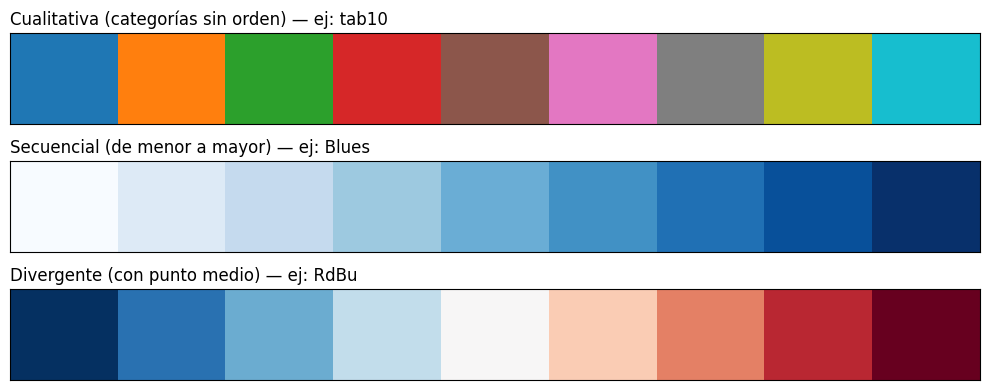

In [9]:
# Datos para ilustrar los tres tipos de paleta
datos = np.array([[1, 2, 3, 4, 5, 6, 7, 8, 9]])

fig, axes = plt.subplots(3, 1, figsize=(10, 4))

# 1) CUALITATIVA: para categorías sin orden (países, productos…)
axes[0].imshow(datos, cmap='tab10', aspect='auto')
axes[0].set_title('Cualitativa (categorías sin orden) — ej: tab10', loc='left')
axes[0].set_yticks([]); axes[0].set_xticks([])

# 2) SECUENCIAL: para magnitudes que van de menos a más
axes[1].imshow(datos, cmap='Blues', aspect='auto')
axes[1].set_title('Secuencial (de menor a mayor) — ej: Blues', loc='left')
axes[1].set_yticks([]); axes[1].set_xticks([])

# 3) DIVERGENTE: para datos con un punto medio (ej: pérdida vs ganancia)
axes[2].imshow(datos, cmap='RdBu_r', aspect='auto')
axes[2].set_title('Divergente (con punto medio) — ej: RdBu', loc='left')
axes[2].set_yticks([]); axes[2].set_xticks([])

plt.tight_layout()
plt.show()

### Accesibilidad: pensar en daltonismo

Aproximadamente el **8% de los hombres** y el **0.5% de las mujeres** tienen algún tipo de daltonismo. La combinación rojo/verde es la más problemática.

Las paletas como `viridis`, `cividis` o `tab10` están diseñadas para ser legibles incluso con daltonismo.

/tmp/ipykernel_10147/3866751215.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10147/3866751215.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


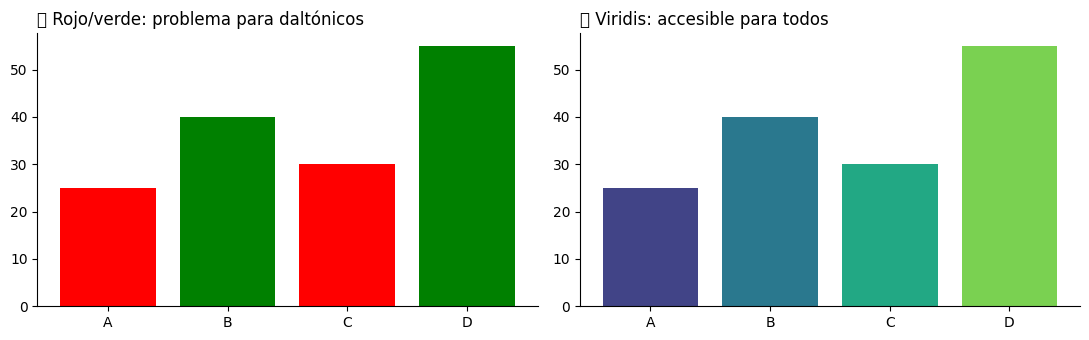

In [10]:
# ❌ MALA PRÁCTICA: rojo y verde son indistinguibles para daltónicos
# ✅ BUENA PRÁCTICA: paletas perceptualmente uniformes (viridis)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

categorias = ['A', 'B', 'C', 'D']
valores = [25, 40, 30, 55]

# Mala paleta: rojo + verde
axes[0].bar(categorias, valores, color=['red', 'green', 'red', 'green'])
axes[0].set_title('❌ Rojo/verde: problema para daltónicos', loc='left')

# Buena paleta: viridis (segura para daltonismo)
axes[1].bar(categorias, valores, color=sns.color_palette('viridis', 4))
axes[1].set_title('✅ Viridis: accesible para todos', loc='left')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Tipografía clara y legible

La jerarquía tipográfica (tamaño, peso) ayuda al lector a identificar rápidamente qué leer primero.

Una escala recomendada:

| Elemento | Tamaño aprox. | Peso |
|---|---|---|
| Título principal   | 16–18 pt | bold |
| Subtítulo          | 13–14 pt | semibold |
| Etiquetas de datos | 10–11 pt | normal |
| Notas al pie       |  8–9 pt  | normal o italic |

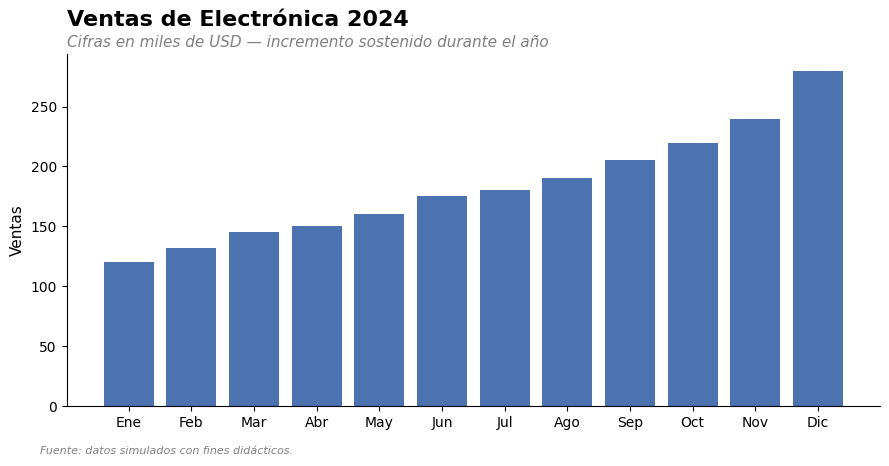

In [11]:
# Aplicamos la jerarquía tipográfica en un gráfico real
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(ventas['Mes'], ventas['Electrónica'], color='#4c72b0')

# Título principal: el más grande y en negrita
ax.set_title('Ventas de Electrónica 2024',
             fontsize=16, fontweight='bold', loc='left', pad=20)

# Subtítulo: explica el contenido (truco: usar text() porque matplotlib
# no tiene un "set_subtitle" oficial)
ax.text(0, 1.02, 'Cifras en miles de USD — incremento sostenido durante el año',
        transform=ax.transAxes, fontsize=11, color='gray', style='italic')

# Etiquetas de los ejes: tamaño intermedio
ax.set_ylabel('Ventas', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

# Nota al pie: la más pequeña
fig.text(0.05, -0.02, 'Fuente: datos simulados con fines didácticos.',
         fontsize=8, color='gray', style='italic')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Espacios en blanco

El espacio vacío **no es desperdicio**. Aporta:

- 📖 Mejor legibilidad.
- 😌 Menor fatiga visual.
- 🎯 Separación lógica entre elementos.
- 👁️ Foco en el contenido importante.

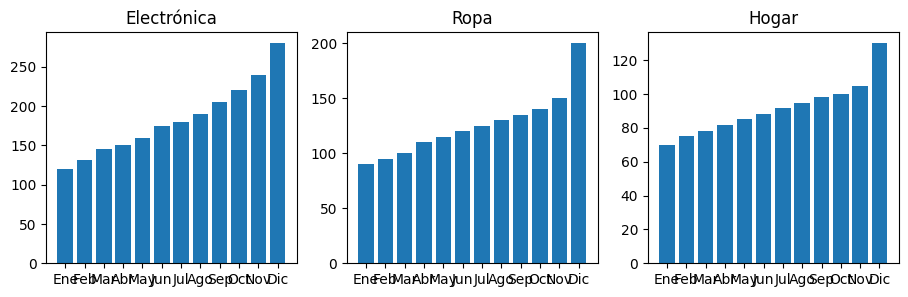

In [12]:
# ❌ MALA PRÁCTICA: gráficos pegados, sin respiración
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for i, cat in enumerate(['Electrónica', 'Ropa', 'Hogar']):
    axes[i].bar(ventas['Mes'], ventas[cat])
    axes[i].set_title(cat)
# OJO: NO usamos tight_layout ni subplots_adjust → los textos se atropellan
plt.show()

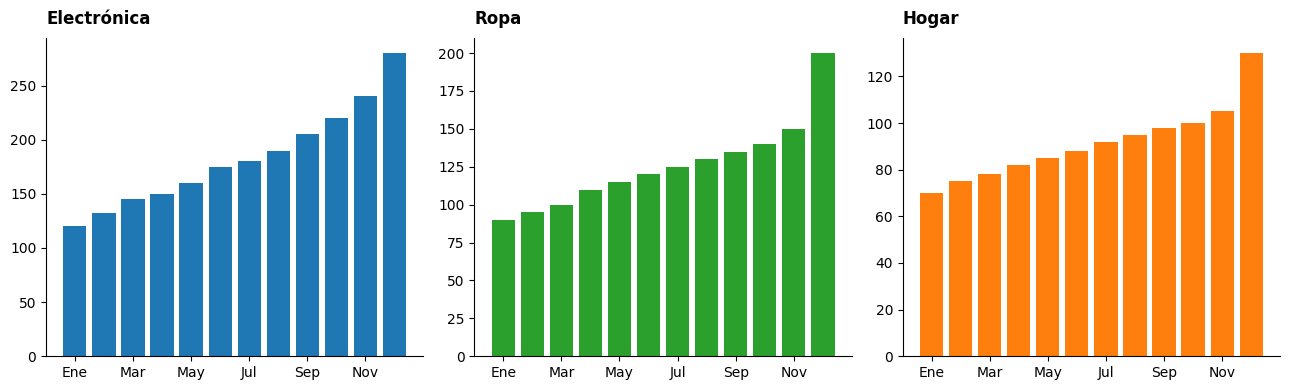

In [13]:
# ✅ BUENA PRÁCTICA: espacio entre gráficos, márgenes generosos
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, cat in enumerate(['Electrónica', 'Ropa', 'Hogar']):
    axes[i].bar(ventas['Mes'], ventas[cat], color=PALETA_CATEGORIAS[cat])
    axes[i].set_title(cat, loc='left', fontweight='bold', pad=10)
    # Mostramos solo cada 2º mes para evitar amontonamiento
    axes[i].set_xticks(range(0, 12, 2))
    axes[i].set_xticklabels(meses[::2])
    for spine in ['top', 'right']:
        axes[i].spines[spine].set_visible(False)

# Espaciado horizontal entre subgráficos
plt.subplots_adjust(wspace=0.35)
plt.tight_layout()
plt.show()

---
## 8. Mostrar solo lo relevante

**Filtra antes de visualizar.** Si un dato no aporta a responder la pregunta del gráfico, sobra.

/tmp/ipykernel_10147/872582507.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10147/872582507.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


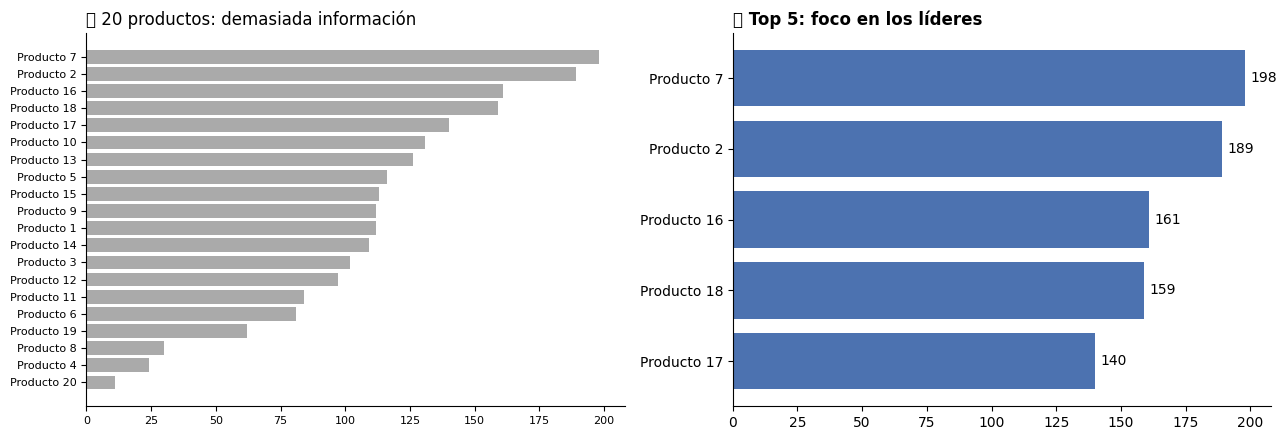

In [14]:
# Imaginemos que tenemos 20 productos pero solo nos interesan los TOP 5
productos = pd.DataFrame({
    'producto': [f'Producto {i}' for i in range(1, 21)],
    'ventas':  np.random.randint(10, 200, 20)
}).sort_values('ventas', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ❌ Mostrar TODO sin filtrar: 20 barras saturan al lector
axes[0].barh(productos['producto'], productos['ventas'], color='#aaaaaa')
axes[0].invert_yaxis()
axes[0].set_title('❌ 20 productos: demasiada información', loc='left')
axes[0].tick_params(labelsize=8)

# ✅ Mostrar solo el TOP 5: foco en lo que importa
top5 = productos.head(5)
axes[1].barh(top5['producto'], top5['ventas'], color='#4c72b0')
axes[1].invert_yaxis()
axes[1].set_title('✅ Top 5: foco en los líderes', loc='left', fontweight='bold')

# Etiquetas de valor al final de cada barra del Top 5
for i, (prod, val) in enumerate(zip(top5['producto'], top5['ventas'])):
    axes[1].text(val + 2, i, str(val), va='center', fontsize=10)

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Errores comunes que debes evitar

### 9.1 Ejes truncados engañosos

Empezar el eje Y en un valor distinto de cero **exagera diferencias** y puede ser engañoso. En gráficos de barras esto es especialmente grave.

/tmp/ipykernel_10147/3929472605.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10147/3929472605.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


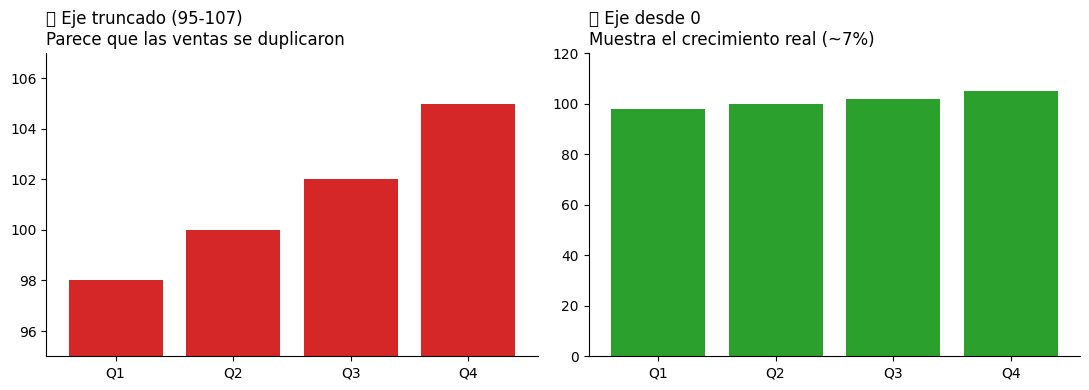

In [15]:
valores = [98, 100, 102, 105]
etiquetas = ['Q1', 'Q2', 'Q3', 'Q4']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ❌ Eje truncado: parece un crecimiento enorme cuando solo es 7%
axes[0].bar(etiquetas, valores, color='#d62728')
axes[0].set_ylim(95, 107)   # ← truncamiento engañoso
axes[0].set_title('❌ Eje truncado (95-107)\nParece que las ventas se duplicaron', loc='left')

# ✅ Eje desde cero: la diferencia real es modesta
axes[1].bar(etiquetas, valores, color='#2ca02c')
axes[1].set_ylim(0, 120)
axes[1].set_title('✅ Eje desde 0\nMuestra el crecimiento real (~7%)', loc='left')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

🚨 **Regla:** en **gráficos de barras**, el eje Y debe iniciar en cero. En **gráficos de líneas** se admite cierto truncamiento si interesa mostrar variaciones pequeñas, pero siempre con claridad.

### 9.2 Demasiadas categorías en un gráfico circular

Los gráficos de torta funcionan **mal** con muchas categorías: el ojo no compara bien ángulos. Recomendación: **máximo 5–7 segmentos**, agrupando el resto como "Otros".

/tmp/ipykernel_10147/4067019194.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10147/4067019194.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


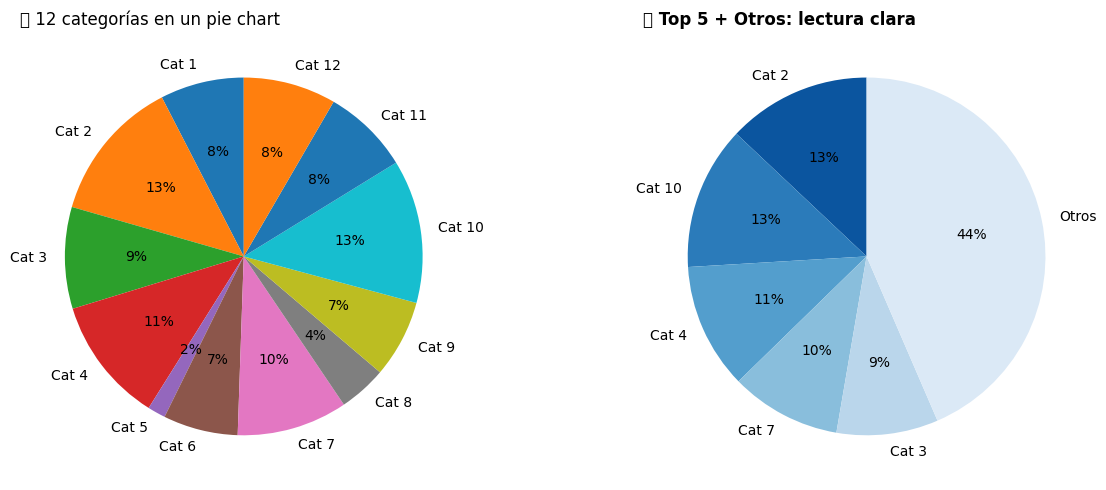

In [16]:
# Generamos 12 categorías para ilustrar el problema
cats_muchas = [f'Cat {i}' for i in range(1, 13)]
vals_muchas = np.random.randint(5, 50, 12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ❌ 12 segmentos: imposible comparar tamaños
axes[0].pie(vals_muchas, labels=cats_muchas, autopct='%1.0f%%', startangle=90)
axes[0].set_title('❌ 12 categorías en un pie chart', loc='left')

# ✅ Top 5 + "Otros": claro y comparable
df_pie = pd.DataFrame({'cat': cats_muchas, 'val': vals_muchas}).sort_values('val', ascending=False)
top5_pie = df_pie.head(5).copy()
otros = pd.DataFrame({'cat': ['Otros'], 'val': [df_pie['val'].iloc[5:].sum()]})
df_pie_final = pd.concat([top5_pie, otros], ignore_index=True)

axes[1].pie(df_pie_final['val'], labels=df_pie_final['cat'],
            autopct='%1.0f%%', startangle=90,
            colors=sns.color_palette('Blues_r', 6))
axes[1].set_title('✅ Top 5 + Otros: lectura clara', loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

### 9.3 Efectos 3D

Los efectos 3D casi siempre **distorsionan la percepción** del tamaño real. Salvo casos muy específicos (por ejemplo, datos genuinamente tridimensionales), evítalos.

Matplotlib lo facilita: por defecto los gráficos son planos. Si ves a alguien usar 3D solo "para que se vea bonito", es probable que esté empeorando la lectura.

---
## 10. Comparación final: gráfico bien vs mal diseñado

Vamos a integrar **todos los principios** en un único ejemplo lado a lado.

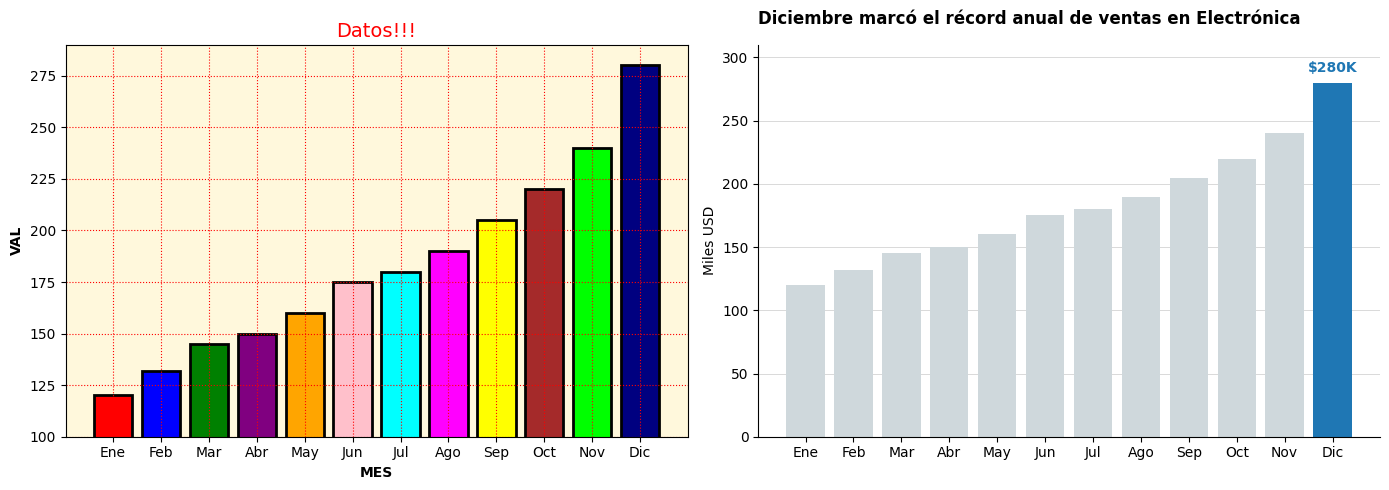

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# ❌ MAL DISEÑADO: acumula casi todos los errores
# ============================================================
ax = axes[0]
ax.set_facecolor('#fff8dc')

# Cada barra de un color distinto sin razón → exceso de colores
colores_random = ['red', 'blue', 'green', 'purple', 'orange',
                  'pink', 'cyan', 'magenta', 'yellow', 'brown',
                  'lime', 'navy']
ax.bar(ventas['Mes'], ventas['Electrónica'],
       color=colores_random, edgecolor='black', linewidth=2)

ax.set_ylim(100, 290)            # Eje truncado: engañoso
ax.set_title('Datos!!!', fontsize=14, color='red')   # Título sin información
ax.grid(True, color='red', linestyle=':')             # Grid chillón
ax.set_xlabel('MES', fontweight='bold')
ax.set_ylabel('VAL', fontweight='bold')

# ============================================================
# ✅ BIEN DISEÑADO: aplica los principios vistos
# ============================================================
ax = axes[1]

# Color uniforme + destacar el máximo
idx_max = ventas['Electrónica'].idxmax()
colores_ok = ['#cfd8dc'] * 12
colores_ok[idx_max] = '#1f77b4'

ax.bar(ventas['Mes'], ventas['Electrónica'], color=colores_ok)

ax.set_ylim(0, 310)              # Eje desde cero
ax.set_title('Diciembre marcó el récord anual de ventas en Electrónica',
             fontsize=12, fontweight='bold', loc='left', pad=15)
ax.set_ylabel('Miles USD', fontsize=10)

# Anotación que ayuda a interpretar
ax.annotate(f'${ventas["Electrónica"].max()}K',
            xy=(idx_max, ventas['Electrónica'].max()),
            xytext=(0, 8), textcoords='offset points',
            ha='center', fontweight='bold', color='#1f77b4')

ax.yaxis.grid(True, color='lightgray', linewidth=0.6)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Diferencias clave

| Aspecto | ❌ Mal diseñado | ✅ Bien diseñado |
|---|---|---|
| Eje Y | Truncado (100-290) | Desde 0 |
| Color | 12 colores aleatorios | 1 color + destacado funcional |
| Título | "Datos!!!" | Cuenta la conclusión |
| Fondo | Crema saturado | Limpio |
| Cuadrícula | Roja punteada | Gris sutil |
| Etiquetas | "VAL", "MES" | "Miles USD" |

---
## 11. Narrativa visual (storytelling)

Una buena visualización no es solo un gráfico, es una **historia con datos**. Sigue esta estructura:

1. **Pregunta**: ¿qué motivó el análisis?
2. **Contexto**: ¿de dónde vienen los datos? ¿qué periodo?
3. **Hallazgos**: ¿qué patrones aparecen?
4. **Acción**: ¿qué decisión sugiere?

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


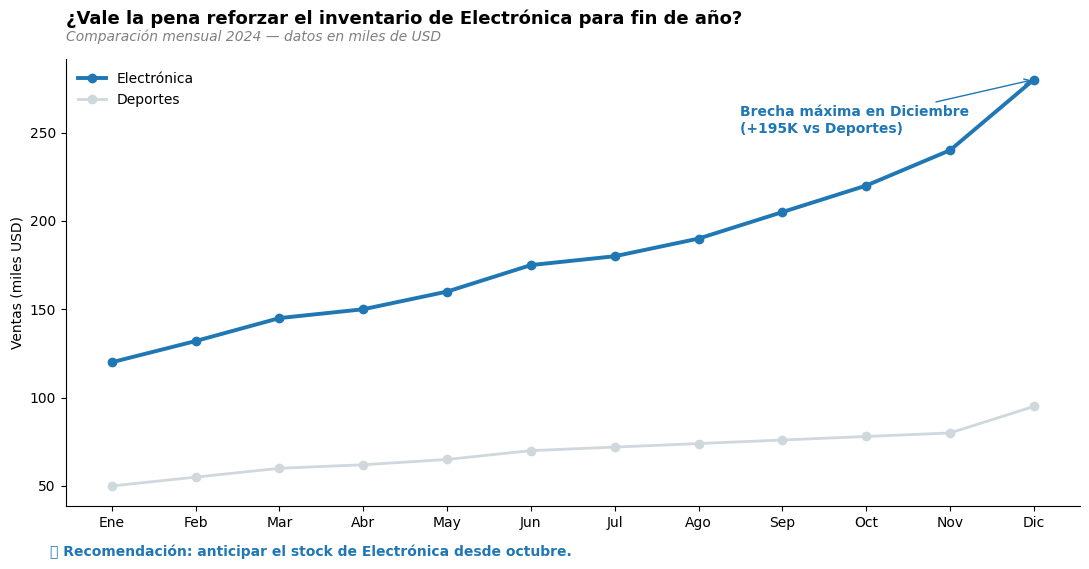

In [18]:
# Ejemplo: gráfico con narrativa completa
fig, ax = plt.subplots(figsize=(11, 5.5))

# Datos protagonistas: Electrónica vs Deportes
ax.plot(ventas['Mes'], ventas['Electrónica'],
        color='#1f77b4', linewidth=2.8, marker='o', label='Electrónica')
ax.plot(ventas['Mes'], ventas['Deportes'],
        color='#cfd8dc', linewidth=2, marker='o', label='Deportes')

# 1) Pregunta como título principal
ax.set_title('¿Vale la pena reforzar el inventario de Electrónica para fin de año?',
             fontsize=13, fontweight='bold', loc='left', pad=25)

# 2) Contexto como subtítulo
ax.text(0, 1.04, 'Comparación mensual 2024 — datos en miles de USD',
        transform=ax.transAxes, fontsize=10, color='gray', style='italic')

# 3) Hallazgo destacado mediante anotación
ax.annotate('Brecha máxima en Diciembre\n(+195K vs Deportes)',
            xy=(11, 280), xytext=(7.5, 250),
            fontsize=10, color='#1f77b4', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1f77b4'))

# 4) Acción como nota al pie
fig.text(0.05, -0.02,
         '💡 Recomendación: anticipar el stock de Electrónica desde octubre.',
         fontsize=10, color='#1f77b4', fontweight='bold')

ax.set_ylabel('Ventas (miles USD)')
ax.legend(frameon=False, loc='upper left')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

---
## 12. Accesibilidad

Una visualización accesible es una **mejor** visualización:

- 🎨 **Contraste**: relación mínima 4.5:1 entre texto y fondo (WCAG).
- 👁️ **Daltonismo**: usa paletas seguras (viridis, cividis, tab10).
- 🔠 **Tamaño legible**: evita texto < 9 pt en pantalla.
- 📝 **Texto alternativo**: al guardar/exportar añade una descripción del gráfico.
- 🔣 **Redundancia**: no dependas SOLO del color (añade etiquetas, formas o patrones).

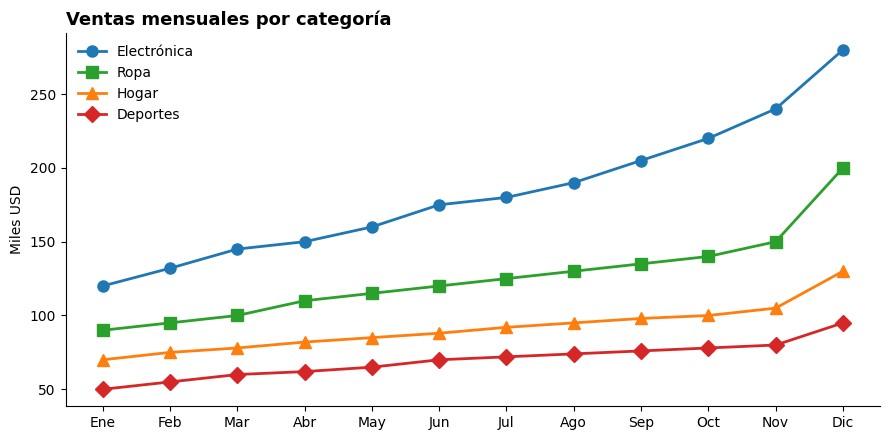

In [19]:
# Ejemplo: redundancia color + marcador
# Si alguien no distingue colores, los marcadores siguen funcionando.

fig, ax = plt.subplots(figsize=(9, 4.5))

marcadores = {'Electrónica': 'o', 'Ropa': 's', 'Hogar': '^', 'Deportes': 'D'}

for cat in ['Electrónica', 'Ropa', 'Hogar', 'Deportes']:
    ax.plot(ventas['Mes'], ventas[cat],
            color=PALETA_CATEGORIAS[cat],
            marker=marcadores[cat],     # ← redundancia visual
            markersize=8, linewidth=2,
            label=cat)

ax.set_title('Ventas mensuales por categoría',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Miles USD')
ax.legend(frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

---
## 13. Checklist final ✅

Antes de publicar cualquier visualización, repasa esta lista:

- [ ] **¿Tiene un propósito claro?** Una pregunta, una respuesta.
- [ ] **¿El título cuenta la conclusión?**
- [ ] **¿Eliminé elementos decorativos** (chartjunk)?
- [ ] **¿Hay jerarquía visual** que guíe la mirada?
- [ ] **¿Los colores son consistentes** entre gráficos del mismo informe?
- [ ] **¿Usé como máximo 5-7 colores distintos?**
- [ ] **¿La paleta es accesible** (apta para daltonismo)?
- [ ] **¿Los ejes parten de cero** (en gráficos de barras)?
- [ ] **¿Las etiquetas son descriptivas** y no abreviadas en exceso?
- [ ] **¿Hay suficiente espacio en blanco**?
- [ ] **¿Filtré datos irrelevantes**?
- [ ] **¿Pasaría la prueba de los 5 segundos** (¿se entiende rápido?)?

---

## 📚 Recursos para seguir aprendiendo

- **Libros**: *The Visual Display of Quantitative Information* (Edward Tufte), *Storytelling with Data* (Cole Nussbaumer Knaflic), *Fundamentals of Data Visualization* (Claus Wilke).
- **Documentación**: matplotlib.org, seaborn.pydata.org, plotly.com/python.
- **Inspiración**: flowingdata.com, informationisbeautiful.net.
- **Paletas accesibles**: colorbrewer2.org.

> *"La visualización es la representación gráfica de la información para amplificar la cognición."* — Card, Mackinlay & Shneiderman